# ipynb/rgcnformer_cls_res_nofont.ipynb - RGCNFormer 分类结果(无字体) / RGCNFormer classification (no font)

## 项目背景 / Background
RGCNFormer 分类结果(无字体)
RGCNFormer classification (no font)

## 功能模块 / Modules
- 无字体版分类结果展示
- (详见各代码单元 / see code cells)

## 输入 / Inputs
- 上一阶段产物(.npy/.pt/.csv/.json)/ prior-stage outputs
- 内嵌常量与参数 / inline constants and params

## 输出 / Outputs
- 图表(内联显示) / figures (inline)
- 中间变量 / intermediate variables
- 导出文件(.png/.pdf/.csv) / exported files

## 数据流 / Data Flow
1. 加载数据 / Load data
2. 运行分析 / Run analysis
3. 渲染图表 / Render figures
4. 导出 / Export

## 相关文件 / Related Files
- 调用 / Calls: ipynb/rgcnformer_cls_res.ipynb
- 被调用 / Called by: 报告 / 论文 / report / paper

## 使用示例 / Usage Example
- 在 JupyterLab 中打开 / open in JupyterLab
- 逐单元运行 / run cells sequentially

## 作者 / Author
项目组 / Project Team

## 版本 / Version
1.0




Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘scales’ was built under R version 4.3.3”
Loading required package: viridisLite

Warning message:
“package ‘viridisLite’ was built under R version 4.3.3”

Attaching package: ‘viridis’


The following object is masked from ‘package:scales’:

    viridis_pal


Warning message:
“package ‘showtext’ was built under R version 4.3.3”
Loading required package: sysfonts

Warning message:
“package ‘sysfonts’ was built under R version 4.3.3”
Loading required package: showtextdb

Warning message:
“package ‘showtextdb’ was built under R version 4.3.3”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


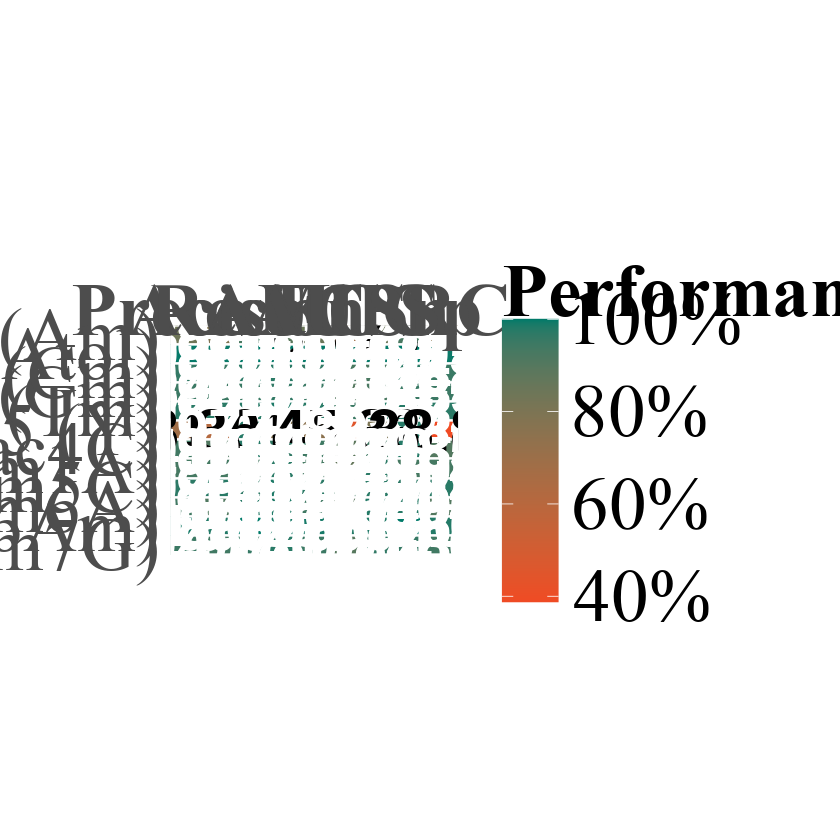

In [1]:
# 加载所需的包
library(ggplot2)
library(dplyr)
library(tidyr)
library(scales)
library(viridis)
library(showtext)

# 2. 注册 Times New Roman 字体
tryCatch({
  font_add("Times New Roman", 
           regular = "/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf", 
           bold = "/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman_Bold.ttf")
  showtext_auto()
}, error = function(e) message("字体加载失败，使用默认字体"))

showtext_opts(dpi = 300)

# 读取数据
df <- read.csv("data/res.csv")

# 定义指标和分类的层级顺序
metric_levels <- c("Acc", "Precision", "Recall", "AUC", "F1", "MCC", "AUPRC", "Sn", "Sp")
class_levels <- unique(df$Class)

# 数据准备：转换为长格式
plot_data <- df %>%
  select(Class, all_of(metric_levels)) %>%
  pivot_longer(cols = -Class, names_to = "Metric", values_to = "Value") %>%
  mutate(
    Metric = factor(Metric, levels = metric_levels),
    Class = factor(Class, levels = rev(class_levels)),
    # 根据背景深浅确定文字颜色：深背景用白色，浅背景用黑色
    # 使用归一化相对值判断
    normalized_value = (Value - min(Value)) / (max(Value) - min(Value)),
    text_color = ifelse(normalized_value > 0.5, "white", "black")
  )

# 创建热图
p <- ggplot(plot_data, aes(x = Metric, y = Class, fill = Value)) +
  # 绘制热图方格
  geom_tile(color = "white", size = 0.5) +
  # 添加数值标注，保留两位小数的百分比
  geom_text(aes(label = sprintf("%.2f", Value * 100), color = text_color),
            size = 5, fontface = "bold") +
  # 使用自定义配色方案（最高值#007A69，最低值#F04B24）
  scale_fill_gradient(low = "#F04B24", high = "#007A69",
                      limits = c(min(plot_data$Value), max(plot_data$Value)),
                      labels = scales::percent_format()) +
  # 设置文字颜色（手动指定以覆盖默认）
  scale_color_identity() +
  # 设置X轴在顶部
  scale_x_discrete(position = "top", expand = c(0, 0)) +
  scale_y_discrete(expand = c(0, 0)) +
  # 【方法二】设置固定的格子宽高比（ratio = 宽度/高度，值越小格子越高）
  # 取消下面这行的注释并调整 ratio 值来控制格子高度
  coord_fixed(ratio = 0.6) +  # ratio=1是正方形，<1则更高，>1则更宽
  # 设置主题
  theme_minimal(base_size = 18) +
  theme(
    # 设置全局字体为Times New Roman
    text = element_text(family = "Times New Roman", size = 18),
    axis.text.x = element_text(face = "bold", angle = 0, hjust = 0.5, size = 18),
    axis.text.y = element_text(face = "plain", size = 18),
    axis.title = element_blank(),
    # 移除网格线
    panel.grid = element_blank(),
    panel.border = element_blank(),
    # 图例设置
    legend.position = "right",
    legend.title = element_text(face = "bold", size = 18),
    legend.text = element_text(size = 18),
    legend.key.size = unit(1.2, "cm"),
    # 减少绘图区域的边距
    plot.margin = margin(10, 10, 10, 10)
  ) +
  # 设置图例标题
  labs(fill = "Performance Value (%)")

# 【方法一】调整保存时的 height 参数来控制格子高度
# 增加 height 值会让每个格子变高，减小 height 值会让格子变矮
ggsave("png3/rgcnformer_cls_heatmap_2.pdf", p, width = 14, height = 14, dpi = 300)
ggsave("png3/rgcnformer_cls_heatmap_2.png", p, width = 14, height = 14, dpi = 300)

# 显示热图
print(p)

## 调整格子高度的方法说明

### 方法一：调整 ggsave 的 height 参数（推荐）
- 在代码末尾的 `ggsave()` 函数中调整 `height` 参数
- **增加 height 值**（如从 10 改为 12、14 等）会让格子变高
- **减小 height 值**（如从 10 改为 8、6 等）会让格子变矮

### 方法二：使用 coord_fixed() 固定宽高比
- 取消代码中 `coord_fixed(ratio = 0.8)` 这一行的注释
- `ratio` 参数表示**宽度/高度**的比例
- `ratio = 1`：正方形格子
- `ratio < 1`（如 0.8、0.6）：格子更高（竖长）
- `ratio > 1`（如 1.2、1.5）：格子更宽（横扁）
